Found 6 files belonging to 2 classes.
Using 5 files for training.
Found 6 files belonging to 2 classes.
Using 1 files for validation.
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 0.7960 - precision_4: 0.4000 - recall_4: 1.0000 - val_accuracy: 0.0000e+00 - val_loss: 1.7686 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.8000 - loss: 0.6658 - precision_4: 1.0000 - recall_4: 0.5000 - val_accuracy: 1.0000 - val_loss: 0.0482 - val_precision_4: 1.0000 - val_recall_4: 1.0000 - learning_rate: 0.0010
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8000 - loss: 0.5167 - precision_4: 1.0000 - recall_4: 0.5000 - val_accuracy: 1.0000 - val_loss: 1.9582e-04 - val_precision_4: 1.0000 - val_recall_4: 1.0000 - learning_rate: 0.0010
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - accuracy: 0.8000 - loss: 0.5389 - precision_4: 1.0000 - recall_4: 0.5000 - val_ac

TypeError: only 0-dimensional arrays can be converted to Python scalars

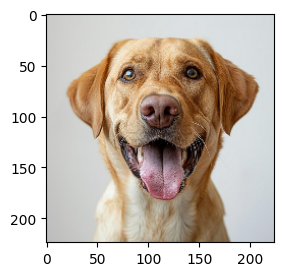

In [5]:
# ==========================================
# Dog vs Cat Classification using VGG16
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -------------------------------
# Step 1: Parameters
# -------------------------------
img_size = (224, 224)
batch_size = 32

# -------------------------------
# Step 2: Load Dataset
# -------------------------------
train_ds = image_dataset_from_directory(
    "dataset/",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    "dataset/",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# ✅ SAVE class names BEFORE mapping
class_names = train_ds.class_names

# -------------------------------
# Step 3: Normalize
# -------------------------------
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# -------------------------------
# Step 4: Data Augmentation
# -------------------------------
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# -------------------------------
# Step 5: Load VGG16
# -------------------------------
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# -------------------------------
# Step 6: Build Model
# -------------------------------
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')   # binary output
])

# -------------------------------
# Step 7: Compile
# -------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# -------------------------------
# Step 8: Callbacks
# -------------------------------
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(patience=3)

# -------------------------------
# Step 9: Train
# -------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, lr_scheduler]
)

# -------------------------------
# Step 10: Evaluate
# -------------------------------
loss, acc, precision, recall = model.evaluate(val_ds)

print("\nAccuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

# -------------------------------
# Step 11: Predict Single Image
# -------------------------------
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction >= 0.5:
        print("It's a Dog 🐶")
    else:
        print("It's a Cat 🐱")

# -------------------------------
# Step 12: Display Predictions
# -------------------------------
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    
    predictions = model.predict(images)
    
    for i in range(6):
        
        ax = plt.subplot(2, 3, i + 1)
        
        # Convert back to original scale
        img = (images[i].numpy() * 255).astype("uint8")
        plt.imshow(img)
        
        # ✅ FIX: sigmoid output (not argmax)
        pred_label = class_names[int(predictions[i] >= 0.5)]
        true_label = class_names[int(labels[i])]
        
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")

plt.show()